# Cell 1 - Markdown

# Phase 2 — Build Latent Database

This notebook builds a latent database for the full PCB dataset using the trained CNN autoencoder.

## Model
- Representation: `ln_phase`
- Autoencoder: `CNN AE`
- Latent dimension: `60`

## Input
- Full dataset (`20k` samples)
- Geometry CSV
- Trained checkpoint

## Output
- CSV database:
  - `simu_index`
  - 17 geometry parameters
  - latent vector `z_0 ... z_59`
- NPZ database:
  - `simu_ids`
  - `geometry`
  - `latents`
  - `freq_hz`

# Cell 2 - Imports and path setup

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# go to project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)

from Sources.dataset import PDNDataset
from Sources.models import CNNAutoencoder

PROJECT_ROOT: /home/tekb/Master_Thesis_KB/CodesAndData


# Cell 3 - Config

In [5]:
EXPERIMENT_NAME = "latent_database_cnn_ln_phase_ld60_full20k"

RUN_CFG = {
    "data_dir": "../../Data/variation",
    "csv_file": "../../Data/parameter.csv",
    "subset_size": None,              # None = FULL dataset
    "subset_sampling": "first",       # ignored when subset_size=None
    "subset_seed": 42,
    "repr_name": "ln_phase",
    "latent_dim": 60,
    "batch_size": 256,
    "checkpoint_path": "../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt",
}

RESULTS_DIR = os.path.join("../../Results", EXPERIMENT_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results dir :", RESULTS_DIR)
print("CSV file    :", RUN_CFG["csv_file"])
print("Data dir    :", RUN_CFG["data_dir"])
print("Checkpoint  :", RUN_CFG["checkpoint_path"])

Results dir : ../../Results/latent_database_cnn_ln_phase_ld60_full20k
CSV file    : ../../Data/parameter.csv
Data dir    : ../../Data/variation
Checkpoint  : ../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt


# Cell 4 - Load full dataset

In [3]:
ds = PDNDataset(
    data_dir=RUN_CFG["data_dir"],
    csv_file=RUN_CFG["csv_file"],
    subset_size=RUN_CFG["subset_size"],   # full 20k
    repr_name=RUN_CFG["repr_name"],
    subset_sampling=RUN_CFG["subset_sampling"],
    subset_seed=RUN_CFG["subset_seed"],
)

loader = DataLoader(
    ds,
    batch_size=RUN_CFG["batch_size"],
    shuffle=False,     # IMPORTANT: keep stable order
    num_workers=0,
    pin_memory=False,
)

print("Dataset loaded.")
print("Number of samples :", len(ds))
print("Input tensor shape:", tuple(ds.impedance_data.shape))
print("Geometry shape    :", tuple(ds.geo_params.shape))
print("Frequency points  :", ds.freq_hz.numel())

Loading S4P files (repr='ln_phase') ...


Parsing Files: 100%|██████████| 20000/20000 [01:36<00:00, 207.75it/s]

Cached dataset saved to: ../../Data/data_cache_ln_phase_FULL_first_seedNA_geo_raw.pt
Cache meta: loaded=20000, skipped=0
Dataset loaded.
Number of samples : 20000
Input tensor shape: (20000, 2, 334)
Geometry shape    : (20000, 17)
Frequency points  : 334


# Cell 5 - Load trained CNN AE checkpoint

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")

model = CNNAutoencoder(latent_dim=RUN_CFG["latent_dim"])
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

stats = {k: v.to(device) for k, v in ckpt["stats"].items()}

print("Checkpoint loaded successfully.")
print("Available stat keys:", list(stats.keys()))

Using device: cuda
Checkpoint loaded successfully.
Available stat keys: ['ch0_mean', 'ch0_std', 'ch1_mean', 'ch1_std']


/tmp/ipykernel_129497/3391053702.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")


# Cell 6 - Normalization helper for ln_phase

In [5]:
def normalize_batch_ln_phase(x: torch.Tensor, stats: dict) -> torch.Tensor:
    x = x.clone()
    x[:, 0, :] = (x[:, 0, :] - stats["ch0_mean"]) / (stats["ch0_std"] + 1e-6)
    x[:, 1, :] = (x[:, 1, :] - stats["ch1_mean"]) / (stats["ch1_std"] + 1e-6)
    return x

# Cell 7 - Extract latent vectors for full 20k

In [6]:
@torch.no_grad()
def extract_latents_full(model, loader, stats, device):
    z_list = []
    sid_list = []
    geo_list = []

    for x, geo, sid in loader:
        x = x.to(device)
        x_norm = normalize_batch_ln_phase(x, stats)

        z = model.encode(x_norm)

        z_list.append(z.cpu().numpy())
        sid_list.append(np.asarray(sid))
        geo_list.append(geo.numpy())

    Z = np.vstack(z_list)              # [N, 60]
    SID = np.concatenate(sid_list)     # [N]
    GEO = np.vstack(geo_list)          # [N, 17]

    return Z, SID, GEO

Z, SID, GEO = extract_latents_full(model, loader, stats, device)

print("Latents extracted.")
print("Z shape   :", Z.shape)
print("SID shape :", SID.shape)
print("GEO shape :", GEO.shape)

Latents extracted.
Z shape   : (20000, 60)
SID shape : (20000,)
GEO shape : (20000, 17)


# Cell 8 - Extracting geometry columns and verify matching 

In [7]:
# Load parameter CSV
param_df = pd.read_csv(RUN_CFG["csv_file"])

# Extract geometry column names (exclude simu_index)
geo_columns = param_df.columns.drop("simu_index").tolist()

print("Geometry columns loaded from CSV:", len(geo_columns))

# Safety check
assert GEO.shape[1] == len(geo_columns), "Mismatch between GEO and CSV columns"
print("Geometry columns ready:", len(geo_columns))

Geometry columns loaded from CSV: 17
Geometry columns ready: 17


In [8]:
# --- Verify alignment between SID and CSV ---
csv_sid = param_df["simu_index"].values

if not np.all(SID.astype(int) == csv_sid):
    print("WARNING: SID order does NOT match CSV order!")
else:
    print("SID order matches CSV order")

SID order matches CSV order


# Cell 9 - Build latent CSV table

In [9]:
# geometry dataframe
geo_df = pd.DataFrame(GEO, columns=geo_columns)

# latent dataframe
latent_columns = [f"z_{i}" for i in range(Z.shape[1])]
latent_df = pd.DataFrame(Z, columns=latent_columns)

# final database table
db_df = pd.concat(
    [
        pd.DataFrame({"simu_index": SID.astype(int)}),
        geo_df,
        latent_df,
    ],
    axis=1
)

print("Database dataframe shape:", db_df.shape)
print(db_df.head())

Database dataframe shape: (20000, 78)
   simu_index      TDIEL     TMET        XWIDTH        YWIDTH  CONDUCTIVITY  \
0      100000  47.827801  4.06844   2856.830078  13788.700195    48504700.0   
1      100001  54.140800  3.16215  12330.099609   8388.450195    55390400.0   
2      100002  44.449100  1.43178  13016.099609  15085.500000    57885400.0   
3      100003  22.193600  1.99590   5841.600098  13638.500000    55821500.0   
4      100004   7.030850  3.68600  17671.300781  11951.299805    48776100.0   

   PERMITTIVITY  LOSSTANGENT  A1_VIARADIUS  A1_ANTIPADRADIUS  ...      z_50  \
0       5.36802     0.013589           9.0              23.0  ... -1.341007   
1       2.89531     0.021205           6.0              15.0  ...  0.106847   
2       4.30586     0.007615           8.0              22.0  ...  2.084573   
3       2.42251     0.023671           9.0              21.0  ...  1.828562   
4       4.92067     0.016524           8.0              15.0  ...  1.639007   

       z_51 

# Cell 10 - Save CSV database

In [10]:
csv_path = os.path.join(RESULTS_DIR, "latent_database_cnn_ln_phase_ld60_full20k.csv")
db_df.to_csv(csv_path, index=False)

print("Saved CSV database to:")
print(csv_path)

Saved CSV database to:
../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv


# Cell 11 - Save NPZ database

In [11]:
npz_path = os.path.join(RESULTS_DIR, "latent_database_cnn_ln_phase_ld60_full20k.npz")

np.savez(
    npz_path,
    simu_ids=SID.astype(np.int64),
    geometry=GEO.astype(np.float32),
    latents=Z.astype(np.float32),
    freq_hz=ds.freq_hz.cpu().numpy(),
)

print("Saved NPZ database to:")
print(npz_path)

Saved NPZ database to:
../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz


# Cell 12 - Quick verification

In [12]:
# verify CSV
csv_check = pd.read_csv(csv_path)
print("CSV loaded back:", csv_check.shape)

# verify NPZ
npz_check = np.load(npz_path)
print("NPZ keys:", npz_check.files)
print("NPZ latents shape:", npz_check["latents"].shape)
print("NPZ simu_ids shape:", npz_check["simu_ids"].shape)
print("NPZ geometry shape:", npz_check["geometry"].shape)

CSV loaded back: (20000, 78)
NPZ keys: ['simu_ids', 'geometry', 'latents', 'freq_hz']
NPZ latents shape: (20000, 60)
NPZ simu_ids shape: (20000,)
NPZ geometry shape: (20000, 17)


In [13]:
# Cross-check consistency
assert np.all(csv_check["simu_index"].values == npz_check["simu_ids"])
print("CSV and NPZ simu_index match")

CSV and NPZ simu_index match


## Output summary

Created two latent database files for the full 20k dataset:

### CSV
Contains:
- `simu_index`
- 17 geometry/material parameters
- `z_0 ... z_59`

### NPZ
Contains:
- `simu_ids`
- `geometry`
- `latents`
- `freq_hz`

These files will be used for:
- nearest-neighbor search
- distance metric development
- latent-space density analysis
- stage-2 geometry-to-latent modeling

## Following cells verifies:

- CSV and NPZ both exist


- shapes are correct


- simu_index order matches


- latent values in CSV and NPZ match


- no NaN/Inf values


- no duplicate simulation IDs


- latent dimensions have reasonable spread


- PCA visualization works from saved data only



In [1]:
# Cell 13 - Load saved latent database files for verification

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Update these paths if needed
# --------------------------------------------------
RESULTS_DIR = "../../Results/latent_database_cnn_ln_phase_ld60_full20k"

csv_path = os.path.join(
    RESULTS_DIR,
    "latent_database_cnn_ln_phase_ld60_full20k.csv"
)

npz_path = os.path.join(
    RESULTS_DIR,
    "latent_database_cnn_ln_phase_ld60_full20k.npz"
)

print("CSV path:", csv_path)
print("NPZ path:", npz_path)

assert os.path.exists(csv_path), f"CSV file not found: {csv_path}"
assert os.path.exists(npz_path), f"NPZ file not found: {npz_path}"

db_check = pd.read_csv(csv_path)
npz_check = np.load(npz_path)

print("\nFiles loaded successfully.")
print("CSV shape:", db_check.shape)
print("NPZ keys:", npz_check.files)

CSV path: ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv
NPZ path: ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz

Files loaded successfully.
CSV shape: (20000, 78)
NPZ keys: ['simu_ids', 'geometry', 'latents', 'freq_hz']


In [2]:
# Cell 14 - Check expected database shapes

Z_npz = npz_check["latents"]
SID_npz = npz_check["simu_ids"]
GEO_npz = npz_check["geometry"]
freq_hz_npz = npz_check["freq_hz"]

print("Latents shape :", Z_npz.shape)
print("Simu IDs shape:", SID_npz.shape)
print("Geometry shape:", GEO_npz.shape)
print("Freq shape    :", freq_hz_npz.shape)

assert Z_npz.shape[0] == db_check.shape[0], "Mismatch: CSV rows and NPZ latent rows"
assert SID_npz.shape[0] == db_check.shape[0], "Mismatch: CSV rows and NPZ simu_ids"
assert GEO_npz.shape[0] == db_check.shape[0], "Mismatch: CSV rows and NPZ geometry rows"
assert Z_npz.shape[1] == 60, "Expected latent dimension = 60"
assert GEO_npz.shape[1] == 17, "Expected geometry dimension = 17"

print("\nShape verification passed.")

Latents shape : (20000, 60)
Simu IDs shape: (20000,)
Geometry shape: (20000, 17)
Freq shape    : (334,)

Shape verification passed.


In [3]:
# Cell 15 - Verify CSV column structure

z_cols = [f"z_{i}" for i in range(60)]

required_cols = ["simu_index"] + z_cols

missing_cols = [c for c in required_cols if c not in db_check.columns]

print("Number of CSV columns:", len(db_check.columns))
print("Number of latent columns found:", len([c for c in db_check.columns if c.startswith("z_")]))

if missing_cols:
    print("Missing columns:")
    print(missing_cols)
else:
    print("All required latent columns are present.")

assert len(missing_cols) == 0, "Some required columns are missing"

Number of CSV columns: 78
Number of latent columns found: 60
All required latent columns are present.


In [4]:
# Cell 16 - Verify simu_index consistency

csv_sids = db_check["simu_index"].values.astype(int)
npz_sids = SID_npz.astype(int)

same_order = np.all(csv_sids == npz_sids)

print("CSV and NPZ simu_index same order:", same_order)

if not same_order:
    mismatch_idx = np.where(csv_sids != npz_sids)[0][:10]
    print("First mismatches:")
    for idx in mismatch_idx:
        print(
            f"row={idx}, CSV={csv_sids[idx]}, NPZ={npz_sids[idx]}"
        )

assert same_order, "CSV and NPZ simu_index do not match"
print("simu_index verification passed.")

CSV and NPZ simu_index same order: True
simu_index verification passed.


In [5]:
# Cell 17 - Verify latent values consistency

Z_csv = db_check[z_cols].values.astype(np.float64)

max_abs_diff = np.max(np.abs(Z_csv - Z_npz))
mean_abs_diff = np.mean(np.abs(Z_csv - Z_npz))

print("Max abs difference between CSV Z and NPZ Z :", max_abs_diff)
print("Mean abs difference between CSV Z and NPZ Z:", mean_abs_diff)

assert max_abs_diff < 1e-5, "Latent values in CSV and NPZ do not match closely"

print("Latent value verification passed.")

Max abs difference between CSV Z and NPZ Z : 4.7528076230207716e-07
Mean abs difference between CSV Z and NPZ Z: 1.9619093596138213e-08
Latent value verification passed.


CSV stores numbers as text, for example:

1.234567

NPZ stores binary floating-point values.

When writing and reading CSV, very tiny rounding differences can appear.

Our differences:

max difference  = 4.75e-7
mean difference = 1.96e-8

are extremely small, so the files are practically identical

In [6]:
# Cell 18 - Check NaN and Inf values

print("Checking CSV numerical values...")

numeric_df = db_check.select_dtypes(include=[np.number])

num_nan_csv = numeric_df.isna().sum().sum()
num_inf_csv = np.isinf(numeric_df.values).sum()

num_nan_npz_Z = np.isnan(Z_npz).sum()
num_inf_npz_Z = np.isinf(Z_npz).sum()

num_nan_geo = np.isnan(GEO_npz).sum()
num_inf_geo = np.isinf(GEO_npz).sum()

print("CSV NaN count      :", num_nan_csv)
print("CSV Inf count      :", num_inf_csv)
print("NPZ latent NaN     :", num_nan_npz_Z)
print("NPZ latent Inf     :", num_inf_npz_Z)
print("NPZ geometry NaN   :", num_nan_geo)
print("NPZ geometry Inf   :", num_inf_geo)

assert num_nan_csv == 0, "CSV contains NaN values"
assert num_inf_csv == 0, "CSV contains Inf values"
assert num_nan_npz_Z == 0, "NPZ latents contain NaN values"
assert num_inf_npz_Z == 0, "NPZ latents contain Inf values"

print("\nNaN/Inf verification passed.")

Checking CSV numerical values...
CSV NaN count      : 0
CSV Inf count      : 0
NPZ latent NaN     : 0
NPZ latent Inf     : 0
NPZ geometry NaN   : 0
NPZ geometry Inf   : 0

NaN/Inf verification passed.


In [7]:
# Cell 19 - Analyze latent dimension statistics

latent_stats = pd.DataFrame({
    "mean": Z_csv.mean(axis=0),
    "std": Z_csv.std(axis=0),
    "min": Z_csv.min(axis=0),
    "max": Z_csv.max(axis=0),
    "range": Z_csv.max(axis=0) - Z_csv.min(axis=0),
}, index=z_cols)

latent_stats["abs_mean"] = latent_stats["mean"].abs()

print("Latent dimension statistics:")
display(latent_stats)

print("\nSummary of latent std:")
print(latent_stats["std"].describe())

std_ratio = latent_stats["std"].max() / latent_stats["std"].min()
print("\nStd max/min ratio:", std_ratio)

Latent dimension statistics:


,mean,std,min,max,range,abs_mean
z_0,0.774978,1.459003,-5.131484,7.894370,13.025854,0.774978
z_1,-1.143303,1.014994,-5.714701,3.239008,8.953709,1.143303
z_2,-0.988468,1.189921,-6.420889,4.513677,10.934566,0.988468
z_3,1.154980,1.240565,-3.970150,6.722537,10.692687,1.154980
z_4,-1.390830,1.784716,-9.263782,5.005409,14.269191,1.390830
z_5,-0.994453,1.328256,-5.549812,4.623576,10.173388,0.994453
z_6,1.020885,1.243380,-6.889461,5.281982,12.171443,1.020885
z_7,-0.542045,1.603462,-5.916432,7.550104,13.466536,0.542045
z_8,0.770285,1.645965,-6.723783,5.878258,12.602041,0.770285
z_9,1.452259,1.413973,-3.556373,8.762933,12.319306,1.452259



Summary of latent std:
count    60.000000
mean      1.452350
std       0.263821
min       0.996549
25%       1.251967
50%       1.405508
75%       1.612373
max       2.164452
Name: std, dtype: float64

Std max/min ratio: 2.1719484873773527


“I checked the standard deviation of each latent dimension. The standard deviations are mostly between 1 and 2.16, with a max/min ratio of about 2.17. This means the latent dimensions have comparable scale, so raw Euclidean distance is not strongly dominated by one dimension.”

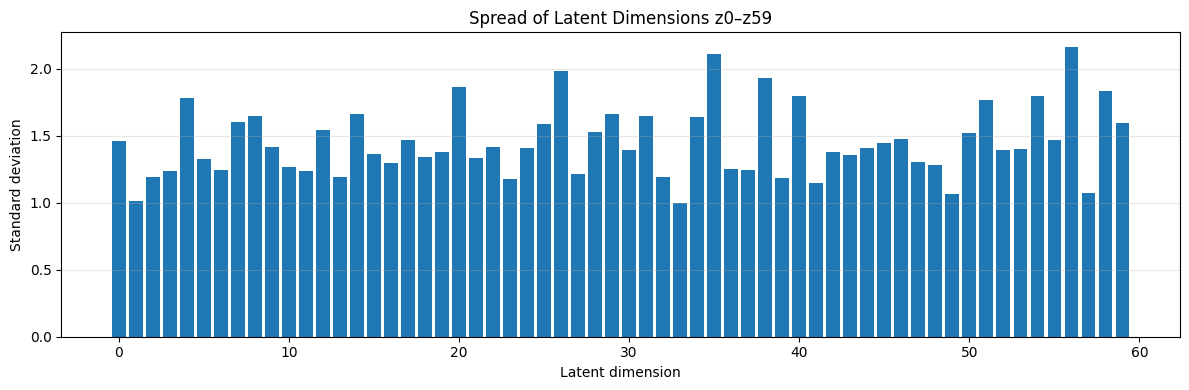

In [8]:
# Cell 20 - Plot latent dimension standard deviations

plt.figure(figsize=(12, 4))
plt.bar(range(60), latent_stats["std"].values)

plt.xlabel("Latent dimension")
plt.ylabel("Standard deviation")
plt.title("Spread of Latent Dimensions z0–z59")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Several latent-space distance metrics were compared by evaluating the impedance similarity of nearest-neighbor samples. For each metric, nearest neighbors were selected in the 60-dimensional latent space, and the average magnitude error in dB was computed between the corresponding impedance profiles. Raw Euclidean distance produced the lowest average neighbor MAE, indicating that it best preserves impedance-profile similarity in the learned latent space. This result is consistent with the observed latent-dimension standard deviations, which showed comparable scaling across dimensions. Therefore, Euclidean distance was selected as the primary distance metric for latent-space similarity analysis.